# MULTIVARIATE ANALYSIS OF VARIANCE

Install and upgrade the pingouin library, useful for statistical tests.

# Install pingouin

In [ ]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.9/198.9 kB 2.0 MB/s eta 0:00:00


# Upgrade pingouin

In [ ]:
pip install pingouin --upgrade

# 6.4.1 ONE WAY MANOVA

# 1. Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, bartlett, levene
from sklearn.covariance import MinCovDet
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# 2. Create and load dataset

In [2]:
data = {
    'plant_var': ['A']*10 + ['B']*10 + ['C']*10 + ['D']*10,
    'height': [
        17.997, 17.362, 18.148, 19.023, 17.266, 17.266, 19.079, 18.267, 17.031, 18.043,  # Group A
        17.037, 17.034, 17.742, 15.587, 15.775, 16.938, 16.487, 17.814, 16.592, 16.088,  # Group B
        18.966, 17.274, 17.568, 16.075, 16.956, 17.611, 16.349, 17.876, 16.899, 17.208,  # Group C
        16.898, 19.352, 17.487, 16.442, 18.323, 16.279, 17.709, 15.540, 16.172, 17.697   # Group D
    ],
    'canopy_vol': [
        0.71, 0.81, 0.92, 0.61, 0.73, 0.77, 0.85, 0.65, 0.98, 0.82,  # Group A
        0.41, 0.56, 0.59, 0.68, 0.69, 0.67, 0.60, 0.62, 0.53, 0.61,  # Group B
        0.11, 0.51, 0.13, 0.23, 0.35, 0.21, 0.15, 0.48, 0.30, 0.33,  # Group C
        0.31, 0.51, 0.56, 0.59, 0.42, 0.35, 0.50, 0.52, 0.55, 0.54   # Group D
    ]
}


# Create DataFrame with the updated data
dfm = pd.DataFrame(data)
# Display the updated DataFrame
print(dfm)

   plant_var  height  canopy_vol
0          A  17.997        0.71
1          A  17.362        0.81
2          A  18.148        0.92
3          A  19.023        0.61
4          A  17.266        0.73
5          A  17.266        0.77
6          A  19.079        0.85
7          A  18.267        0.65
8          A  17.031        0.98
9          A  18.043        0.82
10         B  17.037        0.41
11         B  17.034        0.56
12         B  17.742        0.59
13         B  15.587        0.68
14         B  15.775        0.69
15         B  16.938        0.67
16         B  16.487        0.60
17         B  17.814        0.62
18         B  16.592        0.53
19         B  16.088        0.61
20         C  18.966        0.11
21         C  17.274        0.51
22         C  17.568        0.13
23         C  16.075        0.23
24         C  16.956        0.35
25         C  17.611        0.21
26         C  16.349        0.15
27         C  17.876        0.48
28         C  16.899        0.30
29        

# 3. Boxplots

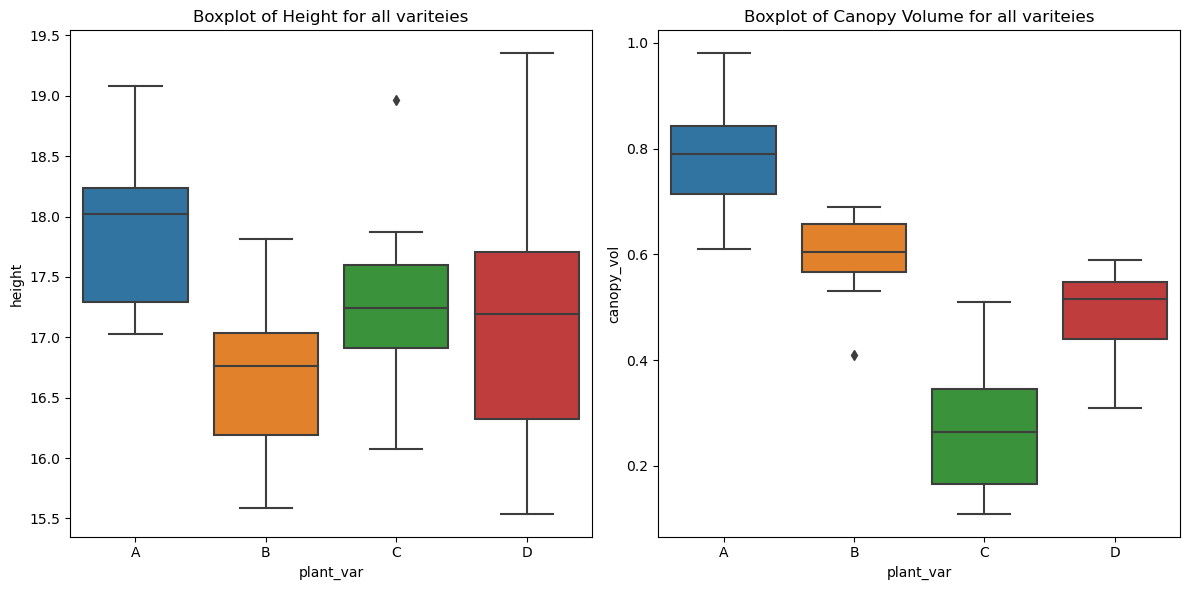

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6)) 

# Boxplot for height
plt.subplot(1, 2, 1) 
sns.boxplot(x='plant_var', y='height', data=dfm)
plt.title('Boxplot of Height for all variteies')

# Boxplot for canopy volume
plt.subplot(1, 2, 2)
sns.boxplot(x='plant_var', y='canopy_vol', data=dfm)
plt.title('Boxplot of Canopy Volume for all variteies')

plt.tight_layout()
plt.show()


# 4. Univariate outlier

In [4]:
# Sample Size Check
print("Sample Size Check:")
print(dfm.groupby('plant_var').size())
print("\n")

# Identify Univariate Outliers using Z-score
def detect_outliers_zscore(data, threshold=3):
    outliers = []
    z_scores = stats.zscore(data)
    for i, z in enumerate(z_scores):
        if np.abs(z) > threshold:
            outliers.append(i)
    return outliers

outliers_height = detect_outliers_zscore(dfm['height'])
outliers_canopy_vol = detect_outliers_zscore(dfm['canopy_vol'])

print(f"Outliers in Height at indices: {outliers_height}")
print(f"Outliers in Canopy Volume at indices: {outliers_canopy_vol}")
print("\n")

# Remove univariate outliers if necessary


Sample Size Check:
plant_var
A    10
B    10
C    10
D    10
dtype: int64


Outliers in Height at indices: []
Outliers in Canopy Volume at indices: []




# 5. Multivariate outlier

In [5]:
# Detect Multivariate Outliers using Mahalanobis Distance
def mahalanobis_distance(df, cov_inv):
    mean = df.mean().values
    md = []
    for index, row in df.iterrows():
        x_minus_mu = row.values - mean
        md.append(mahalanobis(row.values, mean, cov_inv))
    return md

print("Detecting Multivariate Outliers:")
# Calculate covariance matrix and its inverse
cov_matrix = dfm[['height', 'canopy_vol']].cov().values
cov_inv = inv(cov_matrix)

# Calculate Mahalanobis distance
dfm['Mahalanobis'] = mahalanobis_distance(dfm[['height', 'canopy_vol']], cov_inv)

# Determine threshold for outliers (Chi-square with p=0.001 and df=2)
threshold = stats.chi2.ppf(0.999, df=2)
dfm['Outlier'] = dfm['Mahalanobis'] > np.sqrt(threshold)

print(f"Multivariate Outliers Detected: {dfm['Outlier'].sum()} instances")
print(dfm[dfm['Outlier']])
print("\n")

# removing multivariate outliers if required

Detecting Multivariate Outliers:
Multivariate Outliers Detected: 0 instances
Empty DataFrame
Columns: [plant_var, height, canopy_vol, Mahalanobis, Outlier]
Index: []




# 6. Test univariate normality

In [6]:
#Test Univariate Normality (Shapiro-Wilk Test)
print("Testing Univariate Normality:")
for dep in ['height', 'canopy_vol']:
    stat, p = shapiro(dfm[dep])
    print(f"Shapiro-Wilk Test for {dep}: W={stat:.3f}, p-value={p:.3f}")
    if p > 0.05:
        print(f"{dep} is normally distributed.\n")
    else:
        print(f"{dep} is NOT normally distributed.\n")

Testing Univariate Normality:
Shapiro-Wilk Test for height: W=0.979, p-value=0.661
height is normally distributed.

Shapiro-Wilk Test for canopy_vol: W=0.980, p-value=0.695
canopy_vol is normally distributed.



# 7. Multivariate normality

In [7]:
# Test Multivariate Normality (Using Pingouin's multivariate_normality)
print("Testing Multivariate Normality:")
mv_norm_stat = pg.multivariate_normality(dfm[['height', 'canopy_vol']], alpha=0.05)
print(mv_norm_stat)
print("\n")

Testing Multivariate Normality:
HZResults(hz=0.23529633435493413, pval=0.9575405933339186, normal=True)




# 8. Check multicollinearity

In [8]:
# Check Multicollinearity (Correlation Matrix)
print("Checking Multicollinearity:")
corr_matrix = dfm[['height', 'canopy_vol']].corr()
print(corr_matrix)
print("\n")

Checking Multicollinearity:
             height  canopy_vol
height      1.00000     0.10066
canopy_vol  0.10066     1.00000




# 9. Check linearity

Checking Linearity:


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


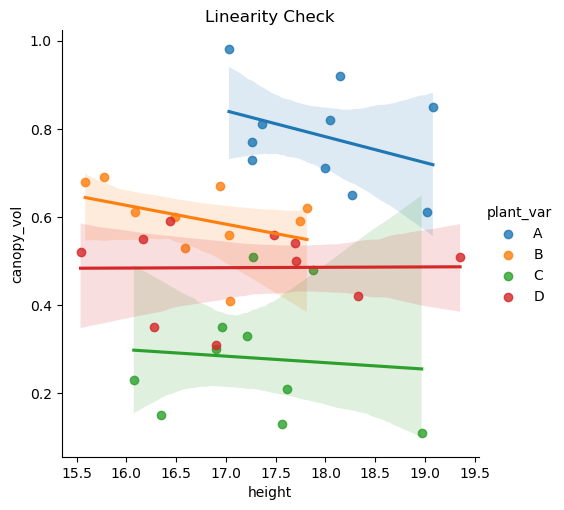

In [9]:
# Check Linearity (Scatter Plot with Regression Line)
print("Checking Linearity:")
sns.lmplot(x='height', y='canopy_vol', hue='plant_var', data=dfm, fit_reg=True)
plt.title('Linearity Check')
plt.show()

# 10. Homogeneity of covariances (Box's M Test)

In [10]:
# Step 9: Check Homogeneity of Covariances (Box's M Test)
print("Checking Homogeneity of Covariances (Box's M Test):")
box_m = pg.box_m(data=dfm, dvs=['height', 'canopy_vol'], group='plant_var')
print(box_m)
print("\n")

Checking Homogeneity of Covariances (Box's M Test):
         Chi2   df      pval  equal_cov
box  6.577519  9.0  0.681012       True




# 11. Homogeneity of variance

In [11]:
# Check Homogeneity of Variances Using Levene's Test
print("Checking Homogeneity of Variance using Levene's Test:")
grouped_data = {group: dfm[dfm['plant_var'] == group] for group in dfm['plant_var'].unique()}

for dep in ['height', 'canopy_vol']:
    data_groups = [group[dep].values for group in grouped_data.values()]
    stat, p = levene(*data_groups, center='mean')
    print(f"Levene's Test for {dep}: W={stat:.3f}, p-value={p:.3f}")
    if p > 0.05:
        print(f"Homogeneity of variance is satisfied for {dep}.")
    else:
        print(f"Homogeneity of variance is not satisfied for {dep}.")
print("\n")

Checking Homogeneity of Variance using Levene's Test:
Levene's Test for height: W=1.177, p-value=0.332
Homogeneity of variance is satisfied for height.
Levene's Test for canopy_vol: W=1.485, p-value=0.235
Homogeneity of variance is satisfied for canopy_vol.




# 12. Running MANOVA

In [12]:
print("Running MANOVA:")
manova = MANOVA.from_formula('height + canopy_vol ~ plant_var', data=dfm)
print(manova.mv_test())
print("\n")

Running MANOVA:
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value   Num DF  Den DF  F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda   0.0067 2.0000 35.0000 2593.0213 0.0000
         Pillai's trace   0.9933 2.0000 35.0000 2593.0213 0.0000
 Hotelling-Lawley trace 148.1726 2.0000 35.0000 2593.0213 0.0000
    Roy's greatest root 148.1726 2.0000 35.0000 2593.0213 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
           plant_var        Value  Num DF  Den DF F Value Pr > F
----------------------------------------------------------------
              Wilks' lambda 0.1890 6.0000 70.0000 15.1689 0.0000
             Pillai's trace 0

# 13. Post-hoc Tests

In [13]:
print("Post-hoc Tests:")
for dep in ['height', 'canopy_vol']:
    print(f"ANOVA for {dep}:")
    model = ols(f'{dep} ~ C(plant_var)', data=dfm).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    print("\n")

    # Levene's test for homogeneity of variances
    from scipy.stats import levene
    _, p_levene = levene(*[dfm[dfm['plant_var'] == group][dep] for group in dfm['plant_var'].unique()])
    print(f"Levene's Test for {dep}: p-value={p_levene:.3f}")

    if p_levene > 0.05:
        print(f"Homogeneity of variances is met. Applying Tukey's HSD for {dep}:")
        tukey = pairwise_tukeyhsd(endog=dfm[dep], groups=dfm['plant_var'], alpha=0.05)
        print(tukey.summary())
    else:
        print(f"Homogeneity of variances is violated. Applying Games-Howell Test for {dep}:")
        games_howell = pg.pairwise_gameshowell(dv=dep, between='plant_var', data=dfm)
        print(games_howell)

    print("\n")


Post-hoc Tests:
ANOVA for height:
                 sum_sq    df         F    PR(>F)
C(plant_var)   7.801887   3.0  3.391312  0.028237
Residual      27.606615  36.0       NaN       NaN


Levene's Test for height: p-value=0.332
Homogeneity of variances is met. Applying Tukey's HSD for height:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B  -1.2388  0.016 -2.2935 -0.1841   True
     A      C    -0.67 0.3331 -1.7247  0.3847  False
     A      D  -0.7583 0.2313  -1.813  0.2964  False
     B      C   0.5688 0.4761 -0.4859  1.6235  False
     B      D   0.4805 0.6142 -0.5742  1.5352  False
     C      D  -0.0883 0.9959  -1.143  0.9664  False
----------------------------------------------------


ANOVA for canopy_vol:
               sum_sq    df          F        PR(>F)
C(plant_var)  1.33737   3.0  36.645294  4.894270e-11
Residual      0.43794  36.0        NaN          

# 6.4.2 TWO WAY MANOVA







# 1. Create and load dataset

In [14]:
data = {
    'plant_var': ['A']*8 + ['B']*8 + ['C']*8 + ['D']*8,  # Varieties
    'block': [
        'Block1', 'Block2', 'Block3', 'Block4', 'Block5', 'Block6', 'Block7', 'Block8',  # Block 1 to 8 for Variety A
        'Block1', 'Block2', 'Block3', 'Block4', 'Block5', 'Block6', 'Block7', 'Block8',  # Block 1 to 8 for Variety B
        'Block1', 'Block2', 'Block3', 'Block4', 'Block5', 'Block6', 'Block7', 'Block8',  # Block 1 to 8 for Variety C
        'Block1', 'Block2', 'Block3', 'Block4', 'Block5', 'Block6', 'Block7', 'Block8',  # Block 1 to 8 for Variety D
    ],
    'height': [
        17.997, 17.362, 18.148, 19.023, 17.266, 17.266, 19.079, 18.267,  # Heights for Variety A
        17.037, 17.034, 17.742, 15.587, 15.775, 16.938, 16.487, 17.814,  # Heights for Variety B
        18.966, 17.274, 17.568, 16.075, 16.956, 17.611, 16.349, 17.876,  # Heights for Variety C
        16.898, 19.352, 17.487, 16.442, 18.323, 16.279, 17.709, 15.540   # Heights for Variety D
    ],
    'canopy_vol': [
        0.71, 0.81, 0.92, 0.61, 0.73, 0.77, 0.85, 0.65,  # Canopy volumes for Variety A
        0.41, 0.56, 0.59, 0.68, 0.69, 0.67, 0.60, 0.62,  # Canopy volumes for Variety B
        0.11, 0.51, 0.13, 0.23, 0.35, 0.21, 0.15, 0.48,  # Canopy volumes for Variety C
        0.31, 0.51, 0.56, 0.59, 0.42, 0.35, 0.50, 0.52   # Canopy volumes for Variety D
    ]
}

# Create DataFrame with the updated data
dfm2 = pd.DataFrame(data)
# Display the updated DataFrame
print(dfm2)

   plant_var   block  height  canopy_vol
0          A  Block1  17.997        0.71
1          A  Block2  17.362        0.81
2          A  Block3  18.148        0.92
3          A  Block4  19.023        0.61
4          A  Block5  17.266        0.73
5          A  Block6  17.266        0.77
6          A  Block7  19.079        0.85
7          A  Block8  18.267        0.65
8          B  Block1  17.037        0.41
9          B  Block2  17.034        0.56
10         B  Block3  17.742        0.59
11         B  Block4  15.587        0.68
12         B  Block5  15.775        0.69
13         B  Block6  16.938        0.67
14         B  Block7  16.487        0.60
15         B  Block8  17.814        0.62
16         C  Block1  18.966        0.11
17         C  Block2  17.274        0.51
18         C  Block3  17.568        0.13
19         C  Block4  16.075        0.23
20         C  Block5  16.956        0.35
21         C  Block6  17.611        0.21
22         C  Block7  16.349        0.15
23         C  Bl

# 2. Boxplot

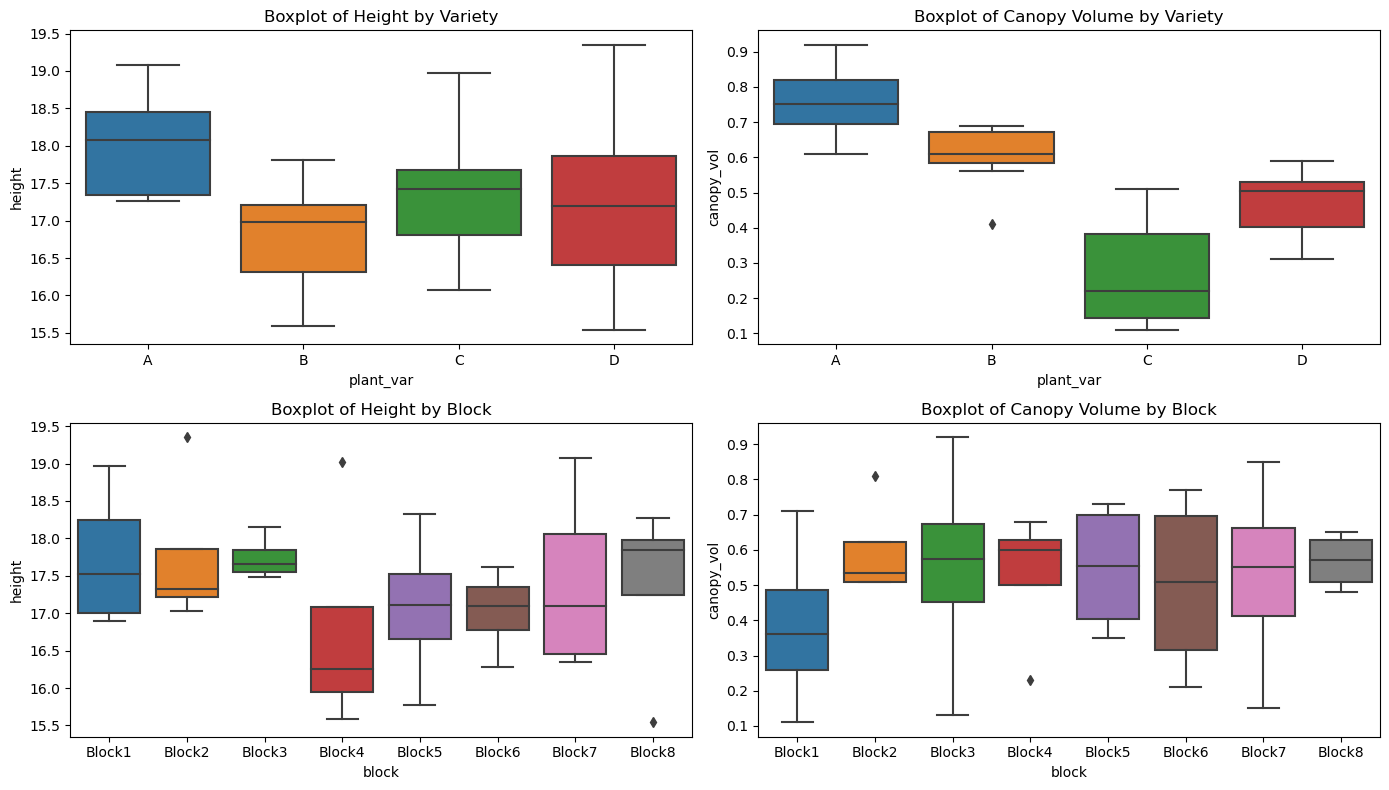

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Boxplot of height by variety
plt.subplot(2, 2, 1)
sns.boxplot(x='plant_var', y='height', data=dfm2)
plt.title('Boxplot of Height by Variety')

# Boxplot of canopy volume by variety
plt.subplot(2, 2, 2)
sns.boxplot(x='plant_var', y='canopy_vol', data=dfm2)
plt.title('Boxplot of Canopy Volume by Variety')

# Boxplot of height by block
plt.subplot(2, 2, 3)
sns.boxplot(x='block', y='height', data=dfm2)
plt.title('Boxplot of Height by Block')

# Boxplot of canopy volume by block
plt.subplot(2, 2, 4)
sns.boxplot(x='block', y='canopy_vol', data=dfm2)
plt.title('Boxplot of Canopy Volume by Block')

plt.tight_layout()
plt.show()


# 3. Univariate outlier

In [16]:
# Sample Size Check
print("Sample Size Check:")
print(dfm2.groupby('plant_var').size())
print("\n")

# Identify Univariate Outliers using Z-score
def detect_outliers_zscore(data, threshold=3):
    outliers = []
    z_scores = stats.zscore(data)
    for i, z in enumerate(z_scores):
        if np.abs(z) > threshold:
            outliers.append(i)
    return outliers

outliers_height = detect_outliers_zscore(dfm2['height'])
outliers_canopy_vol = detect_outliers_zscore(dfm2['canopy_vol'])

print(f"Outliers in Height at indices: {outliers_height}")
print(f"Outliers in Canopy Volume at indices: {outliers_canopy_vol}")
print("\n")

# Remove univariate outliers if necessary


Sample Size Check:
plant_var
A    8
B    8
C    8
D    8
dtype: int64


Outliers in Height at indices: []
Outliers in Canopy Volume at indices: []




# 4. Multivariate outlier

In [17]:
import numpy as np
from scipy import stats
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

def mahalanobis_distance(df, cov_inv):
    mean = df.mean().values
    md = []
    for index, row in df.iterrows():
        x_minus_mu = row.values - mean
        md.append(mahalanobis(row.values, mean, cov_inv))
    return md

print("Detecting Multivariate Outliers:")

# Calculate the covariance matrix and its inverse
cov_matrix = dfm2[['height', 'canopy_vol']].cov().values
cov_inv = inv(cov_matrix)

# Calculate Mahalanobis distance
dfm2['Mahalanobis'] = mahalanobis_distance(dfm2[['height', 'canopy_vol']], cov_inv)

# Determine the threshold for outliers (Chi-square with p=0.001 and df=2)
threshold = stats.chi2.ppf(0.999, df=2)
dfm2['Outlier'] = dfm2['Mahalanobis'] > np.sqrt(threshold)

# Print the number of detected multivariate outliers and details
print(f"Multivariate Outliers Detected: {dfm2['Outlier'].sum()} instances")
print(dfm2[dfm2['Outlier']])
print("\n")

# Optional: Remove multivariate outliers if necessary
remove_multivariate_outliers = False  # Set this to True if you want to remove outliers

if remove_multivariate_outliers:
    dfm2 = dfm2[dfm2['Outlier'] == False].reset_index(drop=True)
    print("Multivariate outliers removed from the dataset.")
else:
    print("Multivariate outliers not removed from the dataset.")


Detecting Multivariate Outliers:
Multivariate Outliers Detected: 0 instances
Empty DataFrame
Columns: [plant_var, block, height, canopy_vol, Mahalanobis, Outlier]
Index: []


Multivariate outliers not removed from the dataset.


# 5. Univariate Normality (Shapiro-Wilk Test)

In [18]:
# Test Univariate Normality (Shapiro-Wilk Test)
from scipy.stats import shapiro

# Test Univariate Normality (Shapiro-Wilk Test)
print("Testing Univariate Normality for each dependent variable:")

# Loop through each dependent variable to test normality
for dep in ['height', 'canopy_vol']:
    stat, p = shapiro(dfm2[dep])
    print(f"Shapiro-Wilk Test for {dep}: W={stat:.3f}, p-value={p:.3f}")
    if p > 0.05:
        print(f"{dep} is normally distributed.\n")
    else:
        print(f"{dep} is NOT normally distributed.\n")

Testing Univariate Normality for each dependent variable:
Shapiro-Wilk Test for height: W=0.977, p-value=0.709
height is normally distributed.

Shapiro-Wilk Test for canopy_vol: W=0.968, p-value=0.443
canopy_vol is normally distributed.



# 6. Multivariate Normality (Using Pingouin's multivariate_normality)

In [19]:
# Test Multivariate Normality (Using Pingouin's multivariate_normality)
print("Testing Multivariate Normality for height and canopy_vol:")

# Perform the multivariate normality test
mv_norm_stat = pg.multivariate_normality(dfm2[['height', 'canopy_vol']], alpha=0.05)

# Print the results
print("Multivariate Normality Test Result:")
print(f"Normality: {mv_norm_stat.normal}")
print(f"p-value: {mv_norm_stat.pval:.3f}")

if mv_norm_stat.normal:
    print("\nThe data is multivariate normally distributed.")
else:
    print("\nThe data is NOT multivariate normally distributed.")

Testing Multivariate Normality for height and canopy_vol:
Multivariate Normality Test Result:
Normality: True
p-value: 0.943

The data is multivariate normally distributed.


# 7. Check multicollinearity (correlation matrix)

In [20]:
# Check Multicollinearity (Correlation Matrix)
print("Checking Multicollinearity:")
corr_matrix = dfm[['height', 'canopy_vol']].corr()
print(corr_matrix)
print("\n")

Checking Multicollinearity:
             height  canopy_vol
height      1.00000     0.10066
canopy_vol  0.10066     1.00000




# 8. Check Linearity (Scatter Plot with Regression Line)

Checking Linearity:


C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


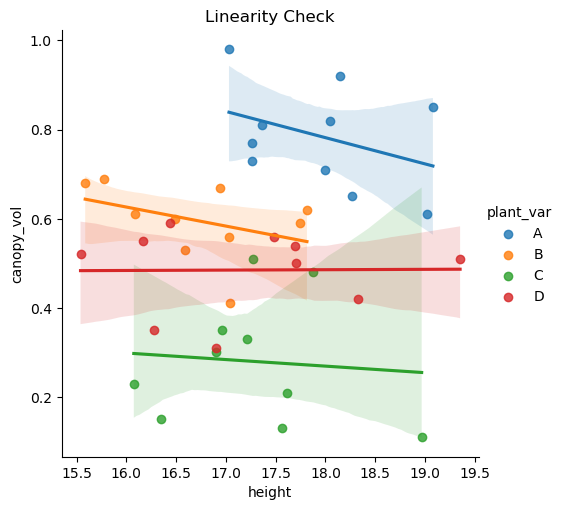

In [21]:
# Check Linearity (Scatter Plot with Regression Line)
print("Checking Linearity:")
sns.lmplot(x='height', y='canopy_vol', hue='plant_var', data=dfm, fit_reg=True)
plt.title('Linearity Check')
plt.show()

# 9. Homogeneity of Covariances (Box's M Test)

In [22]:
# Check Homogeneity of Covariances (Box's M Test)
print("Checking Homogeneity of Covariances (Box's M Test):")
box_m = pg.box_m(data=dfm2, dvs=['height', 'canopy_vol'], group='plant_var')
print(box_m)
print("\n")

Checking Homogeneity of Covariances (Box's M Test):
         Chi2   df      pval  equal_cov
box  5.494549  9.0  0.789244       True




# 10. Homogeneity of Variances Using Levene's Test

In [23]:
# Check Homogeneity of Variances Using Levene's Test
print("Checking Homogeneity of Variance using Levene's Test:")
grouped_data = {group: dfm2[dfm2['plant_var'] == group] for group in dfm2['plant_var'].unique()}

for dep in ['height', 'canopy_vol']:
    data_groups = [group[dep].values for group in grouped_data.values()]
    stat, p = levene(*data_groups, center='mean')
    print(f"Levene's Test for {dep}: W={stat:.3f}, p-value={p:.3f}")
    if p > 0.05:
        print(f"Homogeneity of variance is satisfied for {dep}.")
    else:
        print(f"Homogeneity of variance is not satisfied for {dep}.")
print("\n")

Checking Homogeneity of Variance using Levene's Test:
Levene's Test for height: W=0.854, p-value=0.476
Homogeneity of variance is satisfied for height.
Levene's Test for canopy_vol: W=2.000, p-value=0.137
Homogeneity of variance is satisfied for canopy_vol.




# 11. Running two way MANOVA

In [24]:
from statsmodels.multivariate.manova import MANOVA
# Running Two-Way MANOVA
print("Running Two-Way MANOVA:")
manova = MANOVA.from_formula('height + canopy_vol ~ plant_var * block', data=dfm2)
print(manova.mv_test())
print("\n")


Running Two-Way MANOVA:
                              Multivariate linear model
                                                                                      
----------------------------------------------------------------------------------------
            Intercept                 Value           Num DF   Den DF   F Value   Pr > F
----------------------------------------------------------------------------------------
               Wilks' lambda                -0.0000   1.0000   0.0000   -0.0000      nan
              Pillai's trace                 1.0019   1.0000   0.0000   -0.0000      nan
      Hotelling-Lawley trace   -50039995859673.1797   1.0000   0.0000   -0.0000      nan
         Roy's greatest root                 0.0019   1.0000   0.0000    0.0000      nan
--------------------------------------------------------------------------------------
                                                                                      
------------------------------------

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:198: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:198: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\multivariate\multivariate_ols.py:198: RuntimeWarning: invalid value encountered in power
  lmd = np.power(lmd, 1 / t)


In [25]:
manova_simple = MANOVA.from_formula('height + canopy_vol ~ plant_var + block', data=dfm2)
print(manova_simple.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0177 2.0000 20.0000 555.4508 0.0000
         Pillai's trace  0.9823 2.0000 20.0000 555.4508 0.0000
 Hotelling-Lawley trace 55.5451 2.0000 20.0000 555.4508 0.0000
    Roy's greatest root 55.5451 2.0000 20.0000 555.4508 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         plant_var        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.1569 6.0000 40.0000 10.1625 0.0000
           Pillai's trace 1.0021 6.0000 42.0000  7.0293 0.0000
   Hotellin

# 12. Post-hoc Tests

In [26]:
print("Post-hoc Tests:")

# Post-hoc for main effects and interactions
for dep in ['height', 'canopy_vol']:
    print(f"ANOVA for {dep}:")

    # Perform ANOVA for main effects
    model_main = ols(f'{dep} ~ C(plant_var) + C(block)', data=dfm2).fit()
    anova_table_main = sm.stats.anova_lm(model_main, typ=2)
    print(anova_table_main)

    # Check for interaction
    model_interaction = ols(f'{dep} ~ C(plant_var) * C(block)', data=dfm2).fit()
    anova_table_interaction = sm.stats.anova_lm(model_interaction, typ=2)
    print(anova_table_interaction)

    # Levene's test for homogeneity of variances
    _, p_levene = levene(*[dfm2[(dfm2['plant_var'] == plant) & (dfm2['block'] == block)][dep]
                           for plant in dfm2['plant_var'].unique()
                           for block in dfm2['block'].unique()])
    print(f"Levene's Test for {dep}: p-value={p_levene:.3f}")

    if p_levene > 0.05:
        print(f"Homogeneity of variances is met. Applying Tukey's HSD for {dep}:")
        tukey = pairwise_tukeyhsd(endog=dfm2[dep], groups=dfm2['plant_var'], alpha=0.05)
        print(tukey.summary())
    else:
        print(f"Homogeneity of variances is violated. Applying Games-Howell Test for {dep}:")
        games_howell = pg.pairwise_gameshowell(dv=dep, between='plant_var', data=dfm2)
        print(games_howell)

    print("\n")

Post-hoc Tests:
ANOVA for height:
                 sum_sq    df         F    PR(>F)
C(plant_var)   6.408557   3.0  2.149785  0.124289
C(block)       3.836674   7.0  0.551586  0.785870
Residual      20.867155  21.0       NaN       NaN


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1716: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


ValueError: array must not contain infs or NaNs

Note: The NaN error, encountering in the ANOVA table for the "Residual" row's F and PR(>F) columns is not an error in the data, but rather an expected result given the context. In ANOVA, F and p-values for the residual term are inherently undefined because these are essentially the leftovers after accounting for all other factors in the model. Therefore, the ANOVA output typically doesn't show an F statistic or p-value for the residual term and it is normal to see NaN values there.